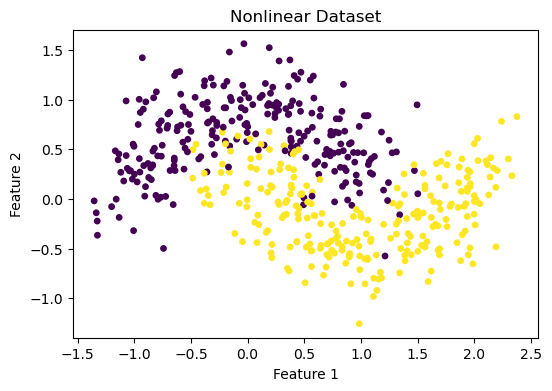

In [11]:
# Overfitting in Deep Learning
# Train, Validation, and Test Set Example Using PyTorch

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# --------------------------------------------------
# 1. Set random seeds
# --------------------------------------------------

np.random.seed(0)
torch.manual_seed(0)


# --------------------------------------------------
# 2. Generate a nonlinear dataset
# --------------------------------------------------

X, y = make_moons(
    n_samples=500,
    noise=0.25,
    random_state=0
)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, s=15)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Nonlinear Dataset")
plt.show()



In [12]:

# --------------------------------------------------
# 3. Split data into train, validation, and test sets
# --------------------------------------------------

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)


# --------------------------------------------------
# 4. Standardize features
# --------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


# --------------------------------------------------
# 5. Convert data to PyTorch tensors
# --------------------------------------------------

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)


# --------------------------------------------------
# 6. Define a high-capacity neural network
# --------------------------------------------------

model = nn.Sequential(
    nn.Linear(2, 128),
    nn.ReLU(),

    nn.Linear(128, 128),
    nn.ReLU(),

    nn.Linear(128, 64),
    nn.ReLU(),

    nn.Linear(64, 2)
)

print(model)



Sequential(
  (0): Linear(in_features=2, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): ReLU()
  (6): Linear(in_features=64, out_features=2, bias=True)
)


In [13]:

# --------------------------------------------------
# 7. Define loss function and optimizer
# --------------------------------------------------

loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


# --------------------------------------------------
# 8. Train the model
# --------------------------------------------------

num_epochs = 1000

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    model.train()

    train_outputs = model(X_train)
    train_loss = loss_function(train_outputs, y_train)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    train_predictions = torch.argmax(train_outputs, dim=1)
    train_accuracy = (
        train_predictions == y_train
    ).float().mean() * 100

    model.eval()

    with torch.no_grad():

        val_outputs = model(X_val)
        val_loss = loss_function(val_outputs, y_val)

        val_predictions = torch.argmax(val_outputs, dim=1)
        val_accuracy = (
            val_predictions == y_val
        ).float().mean() * 100

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    train_accuracies.append(train_accuracy.item())
    val_accuracies.append(val_accuracy.item())

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Train Loss: {train_loss.item():.4f} | "
            f"Val Loss: {val_loss.item():.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Val Acc: {val_accuracy:.2f}%"
        )


# --------------------------------------------------
# 9. Evaluate on the test set
# --------------------------------------------------

model.eval()

with torch.no_grad():

    test_outputs = model(X_test)
    test_predictions = torch.argmax(test_outputs, dim=1)

    test_accuracy = (
        test_predictions == y_test
    ).float().mean() * 100

print()
print(f"Final Test Accuracy: {test_accuracy:.2f}%")


Epoch    0 | Train Loss: 0.6867 | Val Loss: 0.6545 | Train Acc: 50.00% | Val Acc: 51.00%
Epoch  100 | Train Loss: 0.1318 | Val Loss: 0.1441 | Train Acc: 96.00% | Val Acc: 95.00%
Epoch  200 | Train Loss: 0.1055 | Val Loss: 0.1691 | Train Acc: 96.00% | Val Acc: 95.00%
Epoch  300 | Train Loss: 0.0815 | Val Loss: 0.2126 | Train Acc: 96.33% | Val Acc: 94.00%
Epoch  400 | Train Loss: 0.0627 | Val Loss: 0.2738 | Train Acc: 97.67% | Val Acc: 94.00%
Epoch  500 | Train Loss: 0.0431 | Val Loss: 0.3249 | Train Acc: 98.33% | Val Acc: 94.00%
Epoch  600 | Train Loss: 0.0324 | Val Loss: 0.3764 | Train Acc: 99.33% | Val Acc: 94.00%
Epoch  700 | Train Loss: 0.0230 | Val Loss: 0.4139 | Train Acc: 99.33% | Val Acc: 94.00%
Epoch  800 | Train Loss: 0.0173 | Val Loss: 0.4465 | Train Acc: 99.33% | Val Acc: 94.00%
Epoch  900 | Train Loss: 0.0139 | Val Loss: 0.4772 | Train Acc: 99.33% | Val Acc: 94.00%

Final Test Accuracy: 89.00%


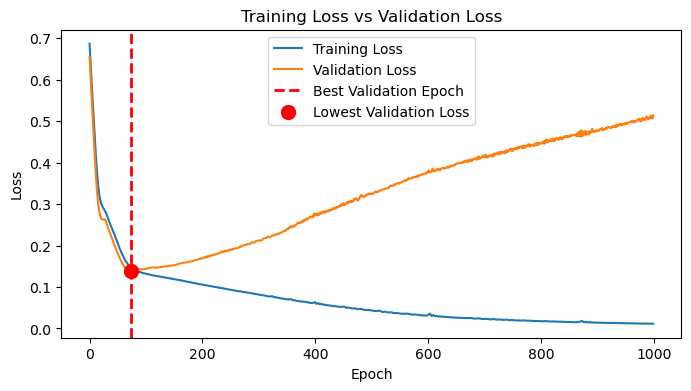

In [14]:


# --------------------------------------------------
# 10. Plot training and validation loss
# --------------------------------------------------

best_epoch = val_losses.index(min(val_losses))
best_val_loss = min(val_losses)

plt.figure(figsize=(8,4))

plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')

plt.axvline(
    x=best_epoch,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Best Validation Epoch'
)

plt.scatter(
    best_epoch,
    best_val_loss,
    s=100,
    color='red',
    zorder=5,
    label='Lowest Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs Validation Loss')
plt.legend()

plt.show()

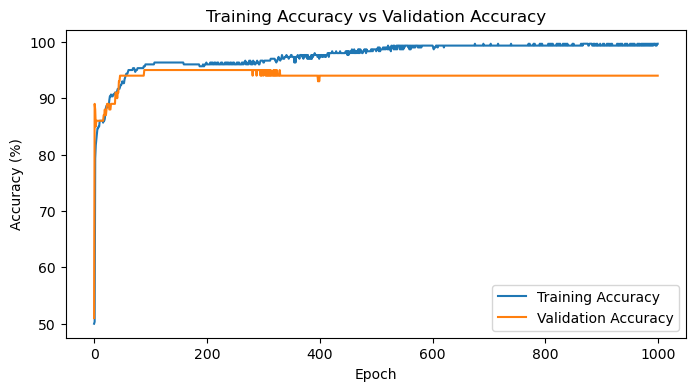

In [15]:


# --------------------------------------------------
# 11. Plot training and validation accuracy
# --------------------------------------------------

plt.figure(figsize=(8, 4))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy vs Validation Accuracy")
plt.legend()

plt.show()



In [16]:

# --------------------------------------------------
# 12. Detect potential overfitting
# --------------------------------------------------

best_val_loss = min(val_losses)
best_epoch = val_losses.index(best_val_loss)

print(f"Lowest Validation Loss: {best_val_loss:.4f}")
print(f"Best Epoch Based on Validation Loss: {best_epoch}")

print()
print("If training loss continues decreasing while validation loss starts increasing,")
print("the model is likely overfitting.")

Lowest Validation Loss: 0.1394
Best Epoch Based on Validation Loss: 73

If training loss continues decreasing while validation loss starts increasing,
the model is likely overfitting.
